In [8]:
import os
from typing import TypedDict, Annotated, Literal
import operator
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

In [4]:
load_dotenv()

True

In [21]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved", "need_improvement"]
    feedback: str
    iteration: int
    max_iterations: int

    tweets_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [12]:
class Evaluator(BaseModel):
    evaluation: Literal["approved", "rejected"]
    feedback: str

In [13]:
model = ChatGroq(model="openai/gpt-oss-120b",)
structured_model = model.with_structured_output(Evaluator)

In [ ]:
def generate_tweet(state: TweetState):
      # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]
    response = model.invoke(messages)
    return {'tweet' : response, 'tweets_history' : [response]}

In [ ]:
def evaluate_tweet(state: TweetState):
    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
        Evaluate the following tweet:

        Tweet: "{state['tweet']}"

        Use the criteria below to evaluate the tweet:

        1. Originality – Is this fresh, or have you seen it a hundred times before?  
        2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
        3. Punchiness – Is it short, sharp, and scroll-stopping?  
        4. Virality Potential – Would people retweet or share it?  
        5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

        Auto-reject if:
        - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
        - It exceeds 280 characters
        - It reads like a traditional setup-punchline joke
        - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

        ### Respond ONLY in structured format:
        - evaluation: "approved" or "needs_improvement"  
        - feedback: One paragraph explaining the strengths and weaknesses 
        """)
        ]
    response = structured_model.invoke(messages)
    return {'evaluation' : response.evaluation, 'feedback' : response.feedback, 'feedback_history' : [response.feedback]}

In [22]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = model.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [23]:
def condition(state: TweetState):
    if state['evaluation'] == "needs_improvement" and state['iteration'] < state['max_iterations']:
        return 'needs_improvement'
    else:
        return 'approved'

In [24]:
graph = StateGraph(TweetState)

graph.add_node('generate_tweet', generate_tweet)
graph.add_node('evaluate_tweet', evaluate_tweet)
graph.add_node('optimize_tweet', optimize_tweet)

graph.add_edge(START, 'generate_tweet')
graph.add_edge('generate_tweet', 'evaluate_tweet')

graph.add_conditional_edges('evaluate_tweet', condition, {'needs_improvement': 'optimize_tweet', 'approved': END})

graph.add_edge('optimize_tweet', 'evaluate_tweet')

app = graph.compile()

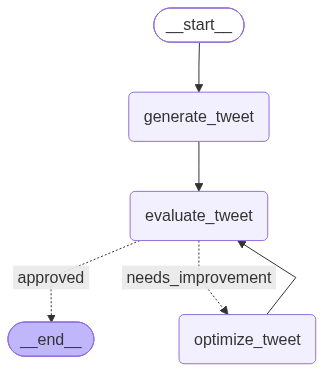

In [19]:
app

In [ ]:
initial_state = {
    'topic': "Indian politics",
    'iteration': 0,
    'max_iterations': 5,
}